In [1]:
import numpy as np
from pymdp.agent import Agent

import imageio
from itertools import product
import random
from IPython.display import Image, display
from collections import deque
import os

# reproducibility
random.seed(42)
np.random.seed(1)

In [2]:
# Build arena mask + mappings (modular arena)

def make_two_rooms_with_corridor(rows=3, left_cols=2, corridor_cols=3, right_cols=2,
                                 corridor_rows=(1),  # tuple/list of row indices that ARE passable in corridor
                                 prefer_total_cols=None):
    """
    Construct a boolean mask for two square rooms (left, right) connected by a corridor.
    Returns mask (rows x total_cols) with True for passable cells and False for blocked.
    corridor_rows: which rows (0-indexed) in the corridor region are allowed to be passable.
                   e.g., (1,2) for two middle rows in a 4-row grid.
    prefer_total_cols: if you need a target total width (e.g. 10), you can supply it and
                       function will try to center corridor; if None, uses left+corridor+right.
    """
    # compute total_cols
    default_total = left_cols + corridor_cols + right_cols
    if prefer_total_cols is None:
        total_cols = default_total
    else:
        total_cols = prefer_total_cols
        # If prefer_total_cols differs from default, we will embed the three regions appropriately
        # We'll place left at col 0, corridor after left, and right at the end so overall fits.
    mask = np.zeros((rows, total_cols), dtype=bool)

    # left room: columns 0 .. left_cols-1 (all rows)
    left_start = 0
    left_end = left_start + left_cols  # exclusive
    mask[:, left_start:left_end] = True

    # corridor: place immediately after left
    corridor_start = left_end
    corridor_end = corridor_start + corridor_cols
    if corridor_end > total_cols:
        raise ValueError("Corridor doesn't fit in prefer_total_cols; increase total width or reduce corridor width.")
    # corridor rows: only allow rows in corridor_rows list (e.g., middle rows)
    for r in corridor_rows:
        mask[r, corridor_start:corridor_end] = True

    # right room: place at the end to make total width sensible
    right_end = total_cols
    right_start = right_end - right_cols
    mask[:, right_start:right_end] = True

    return mask, {"left": (slice(None), slice(left_start, left_end)),
                  "corridor": (slice(None), slice(corridor_start, corridor_end)),
                  "right": (slice(None), slice(right_start, right_end))}

# "T" maze with the perpendicular arm on the right
rows = 4
left_cols = 0
corridor_cols = 3   # corridor width
right_cols = 2
corridor_rows = (1,2)  # allow rows 1 and 2 (middle two rows), top(0) and bottom(3) are blocked in corridor
mask, regions = make_two_rooms_with_corridor(rows=rows, left_cols=left_cols,
                                             corridor_cols=corridor_cols, right_cols=right_cols,
                                             corridor_rows=corridor_rows, prefer_total_cols=None)


print("Arena mask shape:", mask.shape)
print("Passable cells count:", mask.sum())


Arena mask shape: (4, 5)
Passable cells count: 14


In [3]:
# Compact mapping from (r,c) -> state index and back for only passable cells


rows, cols = mask.shape
# create list of valid (r,c) and mapping arrays
valid_rc = [(r, c) for r in range(rows) for c in range(cols) if mask[r, c]]
n_states = len(valid_rc)


# observation modalities -> threat intensity/dist, shelter, agent location
n_threat_obs = 5                         # intensities 0..3 with higher intensity is closer => can make this modular in the future
n_direction_obs = 6 # [none, north, south, east, west, at]
n_shelter_obs = 2 # [NOT AT, AT]
n_agent_obs = n_states

actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

# maps: rc -> compact state id (0..n_states-1), and state->(r,c)
rc_to_state = -np.ones((rows, cols), dtype=int)   # -1 for blocked cells
state_to_rc = [None] * n_states
for i, (r, c) in enumerate(valid_rc):
    rc_to_state[r, c] = i
    state_to_rc[i] = (r, c)

def state_idx_to_rc(idx):
    return state_to_rc[int(idx)]

def rc_to_state_idx(r, c):
    return int(rc_to_state[r, c])

print("n_states (valid cells):", n_states)
print("Sample mapping: first 6 states -> rc:", state_to_rc[:6])


n_states (valid cells): 14
Sample mapping: first 6 states -> rc: [(0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3)]


In [4]:
# step_from_state using neighbor adjacency on masked arena
# actions defined as before: 0=up,1=down,2=left,3=right,4=stay

def step_from_state(state_idx, action):
    r, c = state_idx_to_rc(state_idx)
    if action == 0:   # up
        nr, nc = r - 1, c
    elif action == 1: # down
        nr, nc = r + 1, c
    elif action == 2: # left
        nr, nc = r, c - 1
    elif action == 3: # right
        nr, nc = r, c + 1
    elif action == 4: # stay
        nr, nc = r, c
    else:
        raise ValueError("bad action")

    # If target is outside bounds or blocked, stay in place
    if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
        return state_idx
    if not mask[nr, nc]:
        return state_idx
    return rc_to_state_idx(nr, nc)

# Example sanity checks
for i in range(min(6, n_states)):
    r,c = state_idx_to_rc(i)
    print("state", i, "rc", (r,c), "neighbors:", [step_from_state(i,a) for a in range(len(actions))])


state 0 rc (0, 3) neighbors: [0, 5, 0, 1, 0]
state 1 rc (0, 4) neighbors: [1, 6, 0, 1, 1]
state 2 rc (1, 0) neighbors: [2, 7, 2, 3, 2]
state 3 rc (1, 1) neighbors: [3, 8, 2, 4, 3]
state 4 rc (1, 2) neighbors: [4, 9, 3, 5, 4]
state 5 rc (1, 3) neighbors: [0, 10, 4, 6, 5]


In [5]:
# Build B (object array) using n_states and the new step_from_state function

n_agent = n_states
n_threat = n_states
n_shelter = n_states

n_controls_agent = n_actions
n_controls_threat = 1
n_controls_shelter = 1

# build B_agent: shape (S_next, S_current, n_controls_agent)
B_agent = np.zeros((n_agent, n_agent, n_controls_agent), dtype=float)

for s in range(n_agent):
    for a in range(n_actions):
        ns = step_from_state(s, a)
        # make deterministic-ish with tiny exploration noise
        B_agent[ns, s, a] += 0.99
        # distribute small noise among other reachable neighbors (including stay)
        # find reachable neighbors from s
        neighbors = set(step_from_state(s, aa) for aa in range(n_actions))
        neighbors = sorted(neighbors)
        # distribute 0.01 equally (excluding ns since we already gave 0.99)
        residue = 0.01
        for nb in neighbors:
            if nb == ns:
                continue
            B_agent[nb, s, a] += residue / max(1, (len(neighbors)-1))

# normalize columns for numerical safety
for a in range(n_controls_agent):
    col_sums = B_agent[:, :, a].sum(axis=0)
    # if some column sums slightly != 1 due to rounding, normalize
    for s in range(n_agent):
        if col_sums[s] <= 0:
            B_agent[:, s, a] = 1.0 / n_agent
        else:
            B_agent[:, s, a] /= col_sums[s]

# B for static threat and shelter (identity)
B_threat = np.zeros((n_threat, n_threat, n_controls_threat))
for s in range(n_threat):
    B_threat[s, s, 0] = 1.0

B_shelter = np.zeros((n_shelter, n_shelter, n_controls_shelter))
for s in range(n_shelter):
    B_shelter[s, s, 0] = 1.0

# pack into object array B
B = np.empty(3, dtype=object)
B[0] = B_agent
B[1] = B_threat
B[2] = B_shelter

print("Built B with shapes:")
print(" B_agent:", B_agent.shape, "n_states:", n_agent)


Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14


In [6]:
# Build A modalities using compact state indices but compute manhattan in rc-space

# helper: compute manhattan distance using rc positions
def manhattan_states(s1, s2):
    r1, c1 = state_idx_to_rc(s1)
    r2, c2 = state_idx_to_rc(s2)
    return abs(r1 - r2) + abs(c1 - c2)

# observation sizes
n_threat_obs = 4
n_shelter_obs = 2
n_agent_obs = n_agent  # identity proprioception

A_threat = np.zeros((n_threat_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, t)
            # using same mapping as before but with more flexible arena
            if d == 0:
                A_threat[3, a, t, s] = 1.0
            elif d == 1:
                A_threat[2, a, t, s] = 0.95
                A_threat[1, a, t, s] = 0.05
            elif d == 2:
                A_threat[1, a, t, s] = 0.95
                A_threat[0, a, t, s] = 0.05
            # elif d == 3:
            #     A_threat[1, a, t, s] = 0.9
            #     A_threat[0, a, t, s] = 0.1
            else:
                A_threat[0, a, t, s] = 1.0
A_threat /= A_threat.sum(axis=0, keepdims=True)

# dir mapping (must match render/sampling code)
dir_to_idx = {"none": 0, "north": 1, "south": 2, "west": 3, "east": 4, "at": 5}
n_dir_outcomes = len(dir_to_idx)

# hyperparams
p_dir_correct_total = 1.0   # total mass distributed among valid first steps when smell present
p_dir_none_default = 1.0 - p_dir_correct_total  # leftover mass for 'none' when smell present

# Precompute distance maps from each threat state (use BFS)
def compute_all_distances_from_goal(goal_rc):
    rows_local, cols_local = mask.shape
    dist = np.full((rows_local, cols_local), np.inf, dtype=float)
    if not mask[goal_rc]:
        return dist
    q = deque([goal_rc])
    dist[goal_rc] = 0.0
    while q:
        r,c = q.popleft()
        for nr,nc in [(r-1,c),(r+1,c),(r,c-1),(r,c+1)]:
            if nr < 0 or nr >= rows_local or nc < 0 or nc >= cols_local:
                continue
            if not mask[nr, nc]:
                continue
            if not np.isfinite(dist[nr, nc]):
                dist[nr, nc] = dist[r, c] + 1.0
                q.append((nr, nc))
    return dist

dist_maps_from_threat = [None] * n_threat
for t_idx in range(n_threat):
    t_rc = state_idx_to_rc(t_idx)
    dist_maps_from_threat[t_idx] = compute_all_distances_from_goal(t_rc)

def next_steps_on_shortest_paths(agent_rc, goal_rc, precomputed_dist_to_goal):
    """
    Return list of neighbor rc's of agent_rc that lie on some shortest path to goal_rc.
    Returns [] if agent==goal or unreachable.
    """
    if agent_rc == goal_rc:
        return []
    dist = precomputed_dist_to_goal
    ar, ac = agent_rc
    if not np.isfinite(dist[ar, ac]):
        return []
    agent_dist = dist[ar, ac]
    candidates = []
    for nr,nc in [(ar-1,ac),(ar+1,ac),(ar,ac-1),(ar,ac+1)]:
        if nr < 0 or nr >= mask.shape[0] or nc < 0 or nc >= mask.shape[1]:
            continue
        if not mask[nr, nc]:
            continue
        if np.isfinite(dist[nr, nc]) and dist[nr, nc] == agent_dist - 1:
            candidates.append((nr, nc))
    return candidates

# Build A_direction conditioned on A_threat: if intensity==no-smell (A_threat[0,...]≈1), then direction='none'
A_direction = np.zeros((n_dir_outcomes, n_agent, n_threat, n_shelter))
eps = 1e-9
for a_idx in range(n_agent):
    a_rc = state_idx_to_rc(a_idx)
    for t_idx in range(n_threat):
        # precomputed dist map for this threat
        dist_map = dist_maps_from_threat[t_idx]
        for s_idx in range(n_shelter):
            # if intensity modality predicts 'no smell' with near-certainty, suppress directionality
            p_no_smell = float(A_threat[0, a_idx, t_idx, s_idx])
            if p_no_smell >= (1.0 - 1e-8):
                # directional is silent: all mass on 'none'
                A_direction[:, a_idx, t_idx, s_idx] = 0.0
                A_direction[dir_to_idx["none"], a_idx, t_idx, s_idx] = 1.0
                continue

            # if agent is at the threat -> 'at' deterministic
            if a_idx == t_idx:
                A_direction[:, a_idx, t_idx, s_idx] = 0.0
                A_direction[dir_to_idx["at"], a_idx, t_idx, s_idx] = 1.0
                continue

            # else compute candidate first-steps on shortest paths
            candidates = next_steps_on_shortest_paths(a_rc, state_idx_to_rc(t_idx), precomputed_dist_to_goal=dist_map)
            if len(candidates) == 0:
                # fallback: no path -> none
                A_direction[:, a_idx, t_idx, s_idx] = 0.0
                A_direction[dir_to_idx["none"], a_idx, t_idx, s_idx] = 1.0
                continue

            # allocate directional probabilities among candidates evenly
            per_candidate = float(p_dir_correct_total) / float(len(candidates))
            A_direction[:, a_idx, t_idx, s_idx] = 0.0
            for nb in candidates:
                dr = nb[0] - a_rc[0]
                dc = nb[1] - a_rc[1]
                if dr == -1 and dc == 0:
                    key = "north"
                elif dr == 1 and dc == 0:
                    key = "south"
                elif dr == 0 and dc == -1:
                    key = "west"
                elif dr == 0 and dc == 1:
                    key = "east"
                else:
                    key = "none"
                A_direction[dir_to_idx[key], a_idx, t_idx, s_idx] += per_candidate
            # leftover mass to 'none' (sensor uncertainty)
            A_direction[dir_to_idx["none"], a_idx, t_idx, s_idx] += p_dir_none_default

# Normalize conditionals for safety
A_direction /= (A_direction.sum(axis=0, keepdims=True) + 1e-16)
A_direction[dir_to_idx["none"], (A_direction.sum(axis=0, keepdims=True) <= 1e-12)[0]] = 1.0


# shelter modality (is agent at shelter index?)
A_shelter = np.zeros((n_shelter_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            if a == s:
                A_shelter[1, a, t, s] = 0.8
                A_shelter[0, a, t, s] = 0.2
            else:
                A_shelter[0, a, t, s] = 0.8
                A_shelter[1, a, t, s] = 0.2
A_shelter /= A_shelter.sum(axis=0, keepdims=True)

# agent proprioception: one-hot on compact index
A_agent = np.zeros((n_agent_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    A_agent[a, a, :, :] = 1.0
    # small uniform noise for others
    # A_agent[:, a, :, :] += (0.05 / (n_agent_obs - 1))
A_agent /= A_agent.sum(axis=0, keepdims=True)

# pack into object array
A = np.empty(4, dtype=object)
A[0] = A_threat
A[1] = A_direction
A[2] = A_shelter
A[3] = A_agent

print("Built A with shapes:", [A[i].shape for i in range(4)])


Built A with shapes: [(4, 14, 14, 14), (6, 14, 14, 14), (2, 14, 14, 14), (14, 14, 14, 14)]


In [7]:
# D priors — agent & threat uniform over whole arena; shelter prior = leftmost column

# helper: collect valid states in a column index
def collect_states_in_column(col_idx):
    states = []
    for r in range(rows):
        if 0 <= col_idx < cols and mask[r, col_idx]:
            states.append(rc_to_state_idx(r, col_idx))
    return sorted(states)

# find columns that contain any passable cells
cols_with_passable = np.where(mask.any(axis=0))[0]
if cols_with_passable.size == 0:
    raise RuntimeError("Arena mask has no passable cells.")

leftmost_col = int(cols_with_passable.min())
rightmost_col = int(cols_with_passable.max())

# collect states in leftmost and rightmost columns
leftcol_states = collect_states_in_column(leftmost_col)
rightcol_states = collect_states_in_column(rightmost_col)

print(f"Leftmost column index: {leftmost_col}, states count: {len(leftcol_states)}")
print(f"Rightmost column index: {rightmost_col}, states count: {len(rightcol_states)}")

# --- AGENT & THREAT PRIORS: UNIFORM OVER THE ENTIRE ARENA (clueless)
D_agent = np.ones(n_agent, dtype=float) / float(n_agent)
D_threat = np.ones(n_threat, dtype=float) / float(n_threat)

# --- SHELTER PRIOR: uniform over leftmost column
D_shelter = np.zeros(n_shelter, dtype=float)
if len(leftcol_states) > 0:
    D_shelter[leftcol_states] = 1.0 / len(leftcol_states)


# pack into object array for pymdp
D = np.empty(3, dtype=object)
D[0] = D_agent
D[1] = D_threat
D[2] = D_shelter

print("D shapes:", [D[i].shape for i in range(3)])
print("Agent prior sum:", D_agent.sum(), "Threat prior sum:", D_threat.sum(),
      "Shelter-prior mass on leftcol:", D_shelter.sum())


Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 Threat prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0


In [8]:
# Observation sampler + renderer that support multi-cell shelter region

def sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A):
    """
    Now returns list of ints: [obs_threat_intensity, obs_direction, obs_shelter_presence, obs_agent_loc]
    Supports true_shelter_pos as single int or iterable of ints.
    """
    # normalize shelter positions into a list
    if isinstance(true_shelter_pos, (list, tuple, np.ndarray, set)):
        shelter_indices = sorted(list(true_shelter_pos))
        if len(shelter_indices) == 0:
            shelter_indices = [0]
    else:
        shelter_indices = [int(true_shelter_pos)]

    # modality 0: threat intensity (A[0])
    p_o_threat = np.zeros(A[0].shape[0], dtype=float)
    for s in shelter_indices:
        p_o_threat += A[0][:, true_agent_pos, true_threat_pos, s]
    p_o_threat /= len(shelter_indices)
    p_o_threat = p_o_threat / (np.sum(p_o_threat) + 1e-16)
    obs_threat = int(np.random.choice(len(p_o_threat), p=p_o_threat))

    # modality 1: direction (A[1])
    p_o_dir = np.zeros(A[1].shape[0], dtype=float)
    for s in shelter_indices:
        p_o_dir += A[1][:, true_agent_pos, true_threat_pos, s]
    p_o_dir /= len(shelter_indices)
    p_o_dir = p_o_dir / (np.sum(p_o_dir) + 1e-16)
    obs_dir = int(np.random.choice(len(p_o_dir), p=p_o_dir))

    # modality 2: shelter presence (A[2])
    p_o_shel = np.zeros(A[2].shape[0], dtype=float)
    for s in shelter_indices:
        p_o_shel += A[2][:, true_agent_pos, true_threat_pos, s]
    p_o_shel /= len(shelter_indices)
    p_o_shel = p_o_shel / (np.sum(p_o_shel) + 1e-16)
    obs_shel = int(np.random.choice(len(p_o_shel), p=p_o_shel))

    # modality 3: agent proprio (A[3])
    p_o_agent = np.zeros(A[3].shape[0], dtype=float)
    for s in shelter_indices:
        p_o_agent += A[3][:, true_agent_pos, true_threat_pos, s]
    p_o_agent /= len(shelter_indices)
    p_o_agent = p_o_agent / (np.sum(p_o_agent) + 1e-16)
    obs_agent = int(np.random.choice(len(p_o_agent), p=p_o_agent))

    return [obs_threat, obs_dir, obs_shel, obs_agent]


def render_grid_frame_arena(agent_state, threat_state, shelter_state, visited_states, step,
                            threat_posterior=None, cell_size=48):
    """
    Draw arena, then overlay threat posterior heatmap (semi-transparent),
    then redraw:
      - shelter cells (green),
      - true threat cell (pink with bold outline),
      - agent (blue, top-most).
    This ensures the true threat cell is a single stable visible marker even when the posterior
    colors vary across the last column.
    shelter_state may be a single int or an iterable of ints.
    """
    # normalize shelter_state to a set for membership tests
    if isinstance(shelter_state, (list, tuple, np.ndarray, set)):
        shelter_set = set(int(x) for x in shelter_state)
    else:
        shelter_set = {int(shelter_state)}

    W = cols * cell_size
    H = rows * cell_size
    from PIL import Image, ImageDraw
    img = Image.new('RGB', (W, H), (255,255,255))
    draw = ImageDraw.Draw(img)

    # 1) Draw base grid: blocked cells, visited (light gray), empty cells white.
    for r in range(rows):
        for c in range(cols):
            x0 = c * cell_size
            y0 = r * cell_size
            x1 = x0 + cell_size - 1
            y1 = y0 + cell_size - 1
            if not mask[r, c]:
                fill = (50,50,50)   # blocked cell (dark)
            else:
                idx = rc_to_state_idx(r, c)
                if idx in visited_states and idx not in shelter_set and idx != agent_state and idx != threat_state:
                    fill = (220,220,220)  # visited but not special
                else:
                    fill = (255,255,255)  # default floor
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline=(0,0,0))

    # 2) Overlay heatmap (posterior) as semi-transparent red rectangles (if provided)
    if threat_posterior is not None:
        import numpy as _np
        heat = _np.zeros((rows, cols))
        for s_idx in range(len(threat_posterior)):
            r,c = state_idx_to_rc(s_idx)
            heat[r, c] = float(threat_posterior[s_idx])
        # apply overlay AFTER base drawing
        for r in range(rows):
            for c in range(cols):
                if mask[r, c] and heat[r,c] > 0:
                    x0 = c * cell_size
                    y0 = r * cell_size
                    # scale alpha gently so small probs are faint
                    alpha = min(0.9, float(heat[r,c]) * 2.5)
                    overlay = Image.new('RGBA', (cell_size, cell_size), (255,0,0,int(alpha*200)))
                    img.paste(overlay, (x0, y0), overlay)

    # 3) Redraw shelter cells (green) on top of heatmap so shelter region remains visible
    for s_idx in shelter_set:
        r, c = state_idx_to_rc(s_idx)
        x0 = c * cell_size
        y0 = r * cell_size
        x1 = x0 + cell_size - 1
        y1 = y0 + cell_size - 1
        draw.rectangle([x0, y0, x1, y1], fill=(150,255,150), outline=(0,0,0), width=1)

    # 4) Redraw true threat cell (single) — pink with bold outline so it's immediately obvious
    if threat_state is not None:
        tr = int(threat_state)
        r_t, c_t = state_idx_to_rc(tr)
        x0 = c_t * cell_size
        y0 = r_t * cell_size
        x1 = x0 + cell_size - 1
        y1 = y0 + cell_size - 1
        # pink fill slightly translucent look (we just overpaint)
        draw.rectangle([x0, y0, x1, y1], fill=(255,150,150), outline=(0,0,0), width=2)
        # add a small 'T' label in the center (optional) to further disambiguate
        try:
            # center text roughly
            txt_x = x0 + cell_size // 2 - 6
            txt_y = y0 + cell_size // 2 - 8
            draw.text((txt_x, txt_y), "T", fill=(0,0,0))
        except Exception:
            pass  # if font/drawing fails, ignore

    # 5) Redraw agent ON TOP so it's always visible (blue)
    if agent_state is not None:
        ag = int(agent_state)
        r_a, c_a = state_idx_to_rc(ag)
        x0 = c_a * cell_size
        y0 = r_a * cell_size
        x1 = x0 + cell_size - 1
        y1 = y0 + cell_size - 1
        draw.rectangle([x0, y0, x1, y1], fill=(30,30,200), outline=(0,0,0), width=2)
        try:
            txt_x = x0 + cell_size // 2 - 8
            txt_y = y0 + cell_size // 2 - 8
            draw.text((txt_x, txt_y), "A", fill=(255,255,255))
        except Exception:
            pass

    return np.array(img)


In [9]:
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

# threat_obs outcomes: [none, very far, far, near, at] -> negative increases with closeness
U_threat = np.array([-0.10, -0.11, -0.15, -0.2])  # more negative -> avoid
C_threat = np.log(softmax(U_threat))
# direction: [none, north, south, east, west, at] -> no utility
U_direction = np.array([0.0, 0.0, 0.0, 0.0, 0.0, -0.5])
C_direction = np.log(softmax(U_direction))
# shelter: [not_at, at] -> prefer being at shelter (positive)
U_shelter = np.array([0.5, 1.5]) # positive for being in shelter
C_shelter = np.log(softmax(U_shelter))
# agent proprio: no utility, keep zeros
U_agent = np.zeros(n_agent_obs)
C_agent = np.log(softmax(U_agent))


# make C arrays of shape (n_outcomes, T) - here broadcast across T
T = policy_len = 1
C = [C_threat[:,None].repeat(T,axis=1),
     C_direction[:,None].repeat(T,axis=1),
     C_shelter[:,None].repeat(T,axis=1),
     C_agent[:,None].repeat(T,axis=1)]

print(f"C (log pref): {C}")

# Convert C (list of arrays shape (n_outcomes, T)) to object array with one entry per modality
C_obj = np.empty(4, dtype=object)
C_obj[0] = C[0]   # threat modality log-pref (shape (4,T))
C_obj[1] = C[1]   # direction modality (shape (6,T))
C_obj[2] = C[2]   # shelter modality log-pref (shape (2,T))
C_obj[3] = C[3]   # agent proprio (shape (n_cells,T))

C = C_obj

# Convert D (list) to object array (one per hidden factor)
D_obj = np.empty(3, dtype=object)
D_obj[0] = D_agent
D_obj[1] = D_threat
D_obj[2] = D_shelter

D = D_obj

print("C and D converted to object-arrays for pymdp.")
print("C shapes:", [C[i].shape for i in range(len(C))])
print("D shapes:", [D[i].shape for i in range(len(D))])

C (log pref): [array([[-1.34706398],
       [-1.35706398],
       [-1.39706398],
       [-1.44706398]]), array([[-1.72393211],
       [-1.72393211],
       [-1.72393211],
       [-1.72393211],
       [-1.72393211],
       [-2.22393211]]), array([[-1.31326169],
       [-0.31326169]]), array([[-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733]])]
C and D converted to object-arrays for pymdp.
C shapes: [(4, 1), (6, 1), (2, 1), (14, 1)]
D shapes: [(14,), (14,), (14,)]


In [10]:
# Generate policies for threat task
# n_control_factors = number of hidden-state factors = 3 (agent, threat dummy, shelter dummy)
n_control_factors = 3
num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter]  # [5,1,1]

def generate_policies(n_actions, n_control_factors, policy_len):
    """
    Returns list of arrays shape (policy_len, n_control_factors),
    where first column is agent actions, others are dummy zeros.
    """
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:, 0] = seq   # agent control
        # other factors remain zeros (no control)
        policies.append(pol)
    return policies

policies = generate_policies(n_actions, n_control_factors, policy_len)
n_policies = len(policies)
print(f"Generated {n_policies} policies (h={policy_len}, n_actions={n_actions}).")
print("policy[0] shape:", policies[0].shape)


Generated 5 policies (h=1, n_actions=5).
policy[0] shape: (1, 3)


In [11]:
# BLOCK D: Habit prior (E) represented as decaying Dirichlet counts -> assign to agent_obj.E each step
E_base_count = 1.0
E_counts = np.ones(n_policies) * E_base_count    # Dirichlet-like pseudo-counts

# Hyperparameters (tune these)
E_decay_rate = 0.03        # forgetting speed (0 = never forget; higher -> faster forget)
E_reinforce_amt = 2.0      # bump when hide-after-confirm succeeds

def counts_to_probs(counts):
    return counts / (counts.sum() + 1e-16)

def decay_counts_toward_base(counts, decay_rate, base):
    return (1.0 - decay_rate) * counts + decay_rate * base


In [12]:
# Create the Agent
# control facets: [n_actions, 1, 1]
agent_obj = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    policies = policies,
    policy_len = policy_len,
    num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter],
    control_fac_idx = [0],   # only the agent factor is controllable
    gamma = 4.0,
    alpha = 8.0,
    use_utility = True,
    use_states_info_gain = True
)

print("Agent constructed.")
print("Number of policies:", len(agent_obj.policies))


Agent constructed.
Number of policies: 5


In [13]:
# Run simulation — set agent_obj.E from E_counts before infer_policies()
max_steps = 250
frames = []
history = {'true_state':[], 'beliefs':[], 'actions':[], 'policy_idx':[], 'E_counts':[]}


true_agent_pos = leftcol_states[0]

# Threat true position: single cell in the rightmost column (environment)
true_threat_pos = rightcol_states[0]

# Shelter true positions: ALL passable cells in the leftmost column (environment)
# represent as a list/np.array of compact indices
if len(leftcol_states) > 0:
    true_shelter_pos = np.array(leftcol_states, dtype=int)


visited = {true_agent_pos}

print("Environment truth:")
print("  true_agent_pos (idx, rc):", true_agent_pos, state_idx_to_rc(true_agent_pos))
print("  true_threat_pos (idx, rc):", true_threat_pos, state_idx_to_rc(true_threat_pos))
print("  true_shelter_pos indices count:", len(true_shelter_pos),
      "examples rc:", [state_idx_to_rc(i) for i in true_shelter_pos[:5]])


for t in range(max_steps):
    # 1) sample observation from current true state (the environment emits obs for current state)
    obs = sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A)

    # 2) set Habit prior E from counts (normalized) BEFORE calling infer_policies
    agent_obj.E = counts_to_probs(E_counts)

    # 3) standard pymdp inference calls
    qs = agent_obj.infer_states(obs)         # updates agent_obj.qs
    q_pi_agent, neg_efe = agent_obj.infer_policies()

    # 4) sample policy from q_pi_agent (pymdp already used E internally)
    chosen_policy_idx = int(np.random.choice(len(policies), p=q_pi_agent))
    chosen_policy = policies[chosen_policy_idx]
    chosen_action = int(chosen_policy[0, 0])

    # 5) apply chosen action to the environment (use step_from defined earlier)
    next_agent_pos = step_from_state(true_agent_pos, chosen_action)

    # 6) check threat confirmation
    threat_confirmed = False
    shelter_reached = False

    if isinstance(true_shelter_pos, (list, tuple, np.ndarray, set)):
        shelter_reached = (true_agent_pos in set(true_shelter_pos))
    else:
        shelter_reached = (true_agent_pos == int(true_shelter_pos))
    
    threat_confirmed = (true_agent_pos == int(true_threat_pos))

    if shelter_reached:
        print(f'Shelter reached on step {t}')
    elif threat_confirmed:
        print(f'Threat confirmed on step {t}')

    # 7) forgetting: decay E_counts toward base
    E_counts = decay_counts_toward_base(E_counts, E_decay_rate, E_base_count)

    # 8) record & render
    true_agent_pos = next_agent_pos
    visited.add(true_agent_pos)
    frame_img = render_grid_frame_arena(true_agent_pos, true_threat_pos, true_shelter_pos, visited, t,
                                  threat_posterior=(agent_obj.qs[1] if (hasattr(agent_obj, "qs") and agent_obj.qs is not None) else None))
    frames.append(frame_img)

    history['true_state'].append(true_agent_pos)
    history['beliefs'].append(agent_obj.qs.copy() if hasattr(agent_obj, "qs") else None)
    history['actions'].append(chosen_action)
    history['policy_idx'].append(chosen_policy_idx)
    history['E_counts'].append(E_counts.copy())

    if t % 10 == 0:
        print(f"step {t:03d} | true_agent={true_agent_pos} | action={actions[chosen_action]} | policy_idx={chosen_policy_idx}")
        print(f"  threat_confirmed={threat_confirmed} shelter_reached={shelter_reached}")
        top_idx = np.argsort(E_counts)[-3:][::-1]
        print("  top E_counts (idx, count):", [(int(i), float(E_counts[i])) for i in top_idx])

print("Simulation finished.")


Environment truth:
  true_agent_pos (idx, rc): 2 (1, 0)
  true_threat_pos (idx, rc): 1 (0, 4)
  true_shelter_pos indices count: 2 examples rc: [(1, 0), (2, 0)]
Shelter reached on step 0
step 000 | true_agent=7 | action=down | policy_idx=1
  threat_confirmed=False shelter_reached=True
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
Shelter reached on step 1
Shelter reached on step 2
Shelter reached on step 3
Shelter reached on step 4
Threat confirmed on step 9
step 010 | true_agent=1 | action=up | policy_idx=0
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
Threat confirmed on step 11
step 020 | true_agent=6 | action=stay | policy_idx=4
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2, 1.0)]
Threat confirmed on step 23
step 030 | true_agent=4 | action=up | policy_idx=0
  threat_confirmed=False shelter_reached=False
  top E_counts (idx, count): [(4, 1.0), (3, 1.0), (2

Saved vdir_defeat_arena_p3.gif


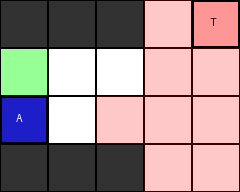

Top policy indices by E (final): [4 3 2 1 0]
4 [[4 0 0]] E_prob=0.2000 count=1.00
3 [[3 0 0]] E_prob=0.2000 count=1.00
2 [[2 0 0]] E_prob=0.2000 count=1.00
1 [[1 0 0]] E_prob=0.2000 count=1.00
0 [[0 0 0]] E_prob=0.2000 count=1.00


In [14]:
# Save gif and print top habit policies
gif_path = "vdir_defeat_arena_p3.gif"
imageio.mimsave(gif_path, frames, fps=10)
print(f"Saved {gif_path}")
display(Image(gif_path))

# final normalized E
E_final = counts_to_probs(E_counts)
topk = 8
top_idx = np.argsort(E_final)[-topk:][::-1]
print("Top policy indices by E (final):", top_idx)
for i in top_idx:
    print(i, policies[i], f"E_prob={E_final[i]:.4f} count={E_counts[i]:.2f}")

In [ ]:
import numpy as np
import math
import matplotlib
matplotlib.use('Agg')   # remove if you want inline interactive plotting
import matplotlib.pyplot as plt
from matplotlib import animation

# ---------- Parameters (RatInABox-like defaults) ----------
rat_params = {
    "dt": 0.05,
    "speed_coherence_time": 0.7,
    "speed_mean": 0.08,
    "speed_std": 0.08,
    "rotational_velocity_coherence_time": 0.08,
    "rotational_velocity_std": 120 * (np.pi / 180.0),  # rad/s
    "head_direction_smoothing_timescale": 0.15,
    "thigmotaxis": 0.5,
    "wall_repel_distance": 0.1,   # in cell units
    "wall_repel_strength": 1.0,
    # visualization
    "cell_size_pixels": 48,
    "agent_radius_frac": 0.2,
    "center_jitter": 0.05,   # fraction of cell to jitter waypoint center
    "max_speed": 0.4,        # safety cap (cells/sec)
}

# ---------- helpers: geometry & mask utilities ----------
def cell_center(rc):
    """Return cell center coords as (y,x) floats in cell units (row,col)"""
    return np.array([rc[0] + 0.5, rc[1] + 0.5], dtype=float)

# Build a list of blocked-cell polygons / centers for repulsion checks
def blocked_cell_centers(mask):
    rows, cols = mask.shape
    centers = []
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                centers.append(np.array([r + 0.5, c + 0.5], dtype=float))
    return np.array(centers) if len(centers) > 0 else np.zeros((0,2))

# distance & vector to nearest blocked-cell center (approx wall repulsion)
_blocked_centers_cache = {}
def nearest_block_vector(pos, mask):
    """
    pos: (y,x) float
    returns: (vector_from_wall, dist) where vector_from_wall points away from nearest blocked center
    """
    key = id(mask)
    if key not in _blocked_centers_cache:
        _blocked_centers_cache[key] = blocked_cell_centers(mask)
    bc = _blocked_centers_cache[key]
    if bc.shape[0] == 0:
        return np.array([0.0, 0.0]), np.inf
    # compute distances
    diffs = bc - pos  # vector from pos to blocked centers
    dists = np.linalg.norm(diffs, axis=1)
    idx = np.argmin(dists)
    dist = float(dists[idx])
    vec_to_block = diffs[idx]
    if dist == 0:
        # at exact center; return arbitrary outward vector
        return -vec_to_block / (np.linalg.norm(vec_to_block) + 1e-8), 0.0
    # vector from wall toward pos (away from blocked center)
    away = -vec_to_block / (dist + 1e-16)
    return away, dist

# ---------- core continuous motion simulator ----------
def continuous_from_discrete(discrete_path, state_to_rc, mask, params=rat_params, random_seed=None):
    """
    Convert discrete cell indices -> continuous time trajectory using simple dynamics.
    Returns:
      positions: Nx2 array of (row, col) continuous coordinates in cell-units (not pixels)
      headings: Nx1 heading angle in radians (0 = +x east, +pi/2 = +y down)
      times: length N array of timestamps (s)
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    dt = float(params["dt"])
    tau_v = float(params["speed_coherence_time"])
    mu_v = float(params["speed_mean"])
    sigma_v = float(params["speed_std"])
    tau_w = float(params["rotational_velocity_coherence_time"])
    sigma_w = float(params["rotational_velocity_std"])
    hd_tau = float(params["head_direction_smoothing_timescale"])
    thigmotaxis = float(params["thigmotaxis"])
    wall_repel_distance = float(params["wall_repel_distance"])
    wall_repel_strength = float(params["wall_repel_strength"])
    center_jitter = float(params["center_jitter"])
    max_speed = float(params.get("max_speed", 0.5))

    # Build sequence of waypoint targets (in continuous coords) from discrete path
    waypoints = []
    for idx in discrete_path:
        rc = state_to_rc[int(idx)]
        c = cell_center(rc)
        # jitter target a bit so the agent does not always land exactly in center
        jitter_vec = (np.random.randn(2) * center_jitter * 0.5)  # small random jitter
        waypoints.append(c + jitter_vec)
    waypoints = np.array(waypoints, dtype=float)

    # For each discrete step we will simulate a fixed number of internal dynamic steps
    # The number of dynamic steps per discrete step depends roughly on distance and dt.
    # We'll simulate until we reach the next waypoint (or max steps)
    positions = []
    headings = []
    times = []

    # initialize state at first waypoint center with small heading
    pos = np.array(waypoints[0], dtype=float)
    # initial heading sample
    heading = np.random.randn() * 0.01
    # OU variables: speed v and angular velocity w
    v = mu_v
    w = 0.0
    # keep smoothed head_direction (unit vector)
    hd_x = math.cos(heading)
    hd_y = math.sin(heading)

    t = 0.0
    positions.append(pos.copy())
    headings.append(heading)
    times.append(t)

    # loop through waypoint targets
    for i in range(1, len(waypoints)):
        target = waypoints[i]
        # run dynamics until we get close enough to target
        max_iter = int(2000)  # safety
        iter_count = 0
        while True:
            iter_count += 1
            if iter_count > max_iter:
                break
            # desired direction vector toward target
            dir_vec = target - pos
            dist_to_target = np.linalg.norm(dir_vec)
            if dist_to_target < 0.05:   # threshold in cell units to consider 'arrived'
                break

            dir_unit = dir_vec / (dist_to_target + 1e-16)
            # compute heading angle toward desired direction
            desired_heading = math.atan2(dir_unit[0], dir_unit[1])  # note: using (row,col) orientation => y first
            # rotate heading gradually via angular velocity dynamics
            # OU update for angular velocity w (rad/s): dw = -(1/τ_w)*w*dt + noise_scale * sqrt(dt) * N(0,1)
            # discrete update:
            w = w + (-(1.0 / tau_w) * w) * dt + sigma_w * math.sqrt(2.0 / tau_w) * np.random.randn() * math.sqrt(dt)
            # apply angular velocity to heading
            heading += w * dt
            # optionally nudge heading toward desired_heading (a soft alignment term)
            # small proportional steering term helps track waypoint:
            steer_gain = 1.2
            ang_diff = (desired_heading - heading + np.pi) % (2 * np.pi) - np.pi
            heading += (steer_gain * 0.5 * ang_diff) * dt

            # OU update for speed v
            v = v + (-(1.0 / tau_v) * (v - mu_v)) * dt + sigma_v * math.sqrt(2.0 / tau_v) * np.random.randn() * math.sqrt(dt)
            v = np.clip(v, 0.0, max_speed)

            # compute wall repulsion force (simple)
            away_vec, dist_wall = nearest_block_vector(pos, mask)
            wall_force = np.array([0.0, 0.0], dtype=float)
            if dist_wall < wall_repel_distance:
                # strength decays linearly with distance
                factor = (1.0 - (dist_wall / (wall_repel_distance + 1e-12)))
                wall_force = away_vec * (wall_repel_strength * factor * (0.5 + thigmotaxis))

            # heading unit vector
            hx = math.cos(heading)
            hy = math.sin(heading)
            # note mapping: heading angle convention uses x=cols, y=rows; dx = hx, dy = hy but when adding to pos (row,col) use (dy,dx)
            vel_vec = np.array([hy, hx], dtype=float) * v  # (row_vel, col_vel)

            # combine velocity and wall_force
            pos = pos + (vel_vec + wall_force) * dt

            # keep inside bounds (clamp to inside mask bounding box)
            rows, cols = mask.shape
            pos[0] = np.clip(pos[0], 0.01, rows - 0.01)
            pos[1] = np.clip(pos[1], 0.01, cols - 0.01)

            # head direction smoothing (low-pass)
            hd_x = hd_x + (math.cos(heading) - hd_x) * (dt / max(dt + 1e-16, hd_tau))
            hd_y = hd_y + (math.sin(heading) - hd_y) * (dt / max(dt + 1e-16, hd_tau))
            hd_norm = math.sqrt(hd_x*hd_x + hd_y*hd_y) + 1e-16
            smoothed_heading = math.atan2(hd_x / hd_norm, hd_y / hd_norm)  # consistent with (row,col) orientation

            # record
            t += dt
            positions.append(pos.copy())
            headings.append(heading)
            times.append(t)

            # safety break if too many points
            if len(times) > 50000:
                break

    return np.array(positions), np.array(headings), np.array(times)

# ---------- plotting helper (draw continuous trajectory) ----------
def plot_continuous_trajectory(positions, mask, state_to_rc=None, shelter_states=None,
                               threat_state=None, cell_size_pixels=48, agent_radius_frac=0.28,
                               savepath=None):
    rows, cols = mask.shape
    fig, ax = plt.subplots(figsize=(cols, rows), dpi=72)
    ax.set_xlim(0, cols)
    ax.set_ylim(rows, 0)
    ax.set_xticks([])
    ax.set_yticks([])
    # draw blocked cells
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                rect = plt.Rectangle((c, r), 1, 1, facecolor=(0.15,0.15,0.15))
                ax.add_patch(rect)
    # shelters
    if shelter_states is not None:
        for s in shelter_states:
            r,c = state_to_rc[int(s)]
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=(0.6, 1.0, 0.6)))
    # threat
    if threat_state is not None:
        r,c = state_to_rc[int(threat_state)]
        ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=(1.0, 0.6, 0.6)))

    # plot path
    ys = positions[:,0]
    xs = positions[:,1]
    ax.plot(xs, ys, '-', linewidth=2, color='royalblue', alpha=0.6)
    # plot agent final position
    rfin, cfin = positions[-1]
    agent_r = agent_radius_frac
    circ = plt.Circle((cfin, rfin), agent_r, color='blue')
    ax.add_patch(circ)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

# ---------- Example usage ----------
discrete_path = history['true_state']  # list of compact indices
positions, headings, times = continuous_from_discrete(discrete_path, state_to_rc, mask, params=rat_params)
plot_continuous_trajectory(positions, mask, state_to_rc=state_to_rc, shelter_states=true_shelter_pos, threat_state=true_threat_pos, savepath='foo.png')


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib.colors as mcolors
import os
import math

def animate_continuous_trajectory_fast(positions, headings=None, mask=None, state_to_rc=None,
                                      shelter_states=None, threat_state=None,
                                      cell_size_pixels=48, agent_radius_frac=0.28,
                                      trail_len=25, fps=20, save_path="continuous_mouse.gif",
                                      save_mp4=False, max_frames=1200, dpi=80, subsample=True):
    """
    Fast animator with fading trail and heading arrow (quiver).
      - positions: (N,2) array of (row, col) floats (cell units)
      - headings: optional (N,) angles in radians (if None, computed from next-step diffs)
      - mask: boolean grid (rows,cols) or None
      - state_to_rc: mapping for shelter/threat drawing if provided
      - trail_len: number of points to show in the fading trail
      - fps: target frames per second
      - save_mp4: if True, try to save MP4 (requires ffmpeg)
      - max_frames: if positions has more frames than this and subsample=True, we subsample
    Returns: path to saved file
    """

    positions = np.asarray(positions, dtype=float)
    n_total = positions.shape[0]
    if n_total < 2:
        raise ValueError("Need at least 2 frames to animate")

    # Subsample frames if there are too many (keeps endpoints)
    if subsample and n_total > max_frames:
        factor = int(math.ceil(n_total / float(max_frames)))
        idxs = np.arange(0, n_total, factor)
        if idxs[-1] != n_total - 1:
            idxs = np.concatenate([idxs, np.array([n_total - 1])])
        positions = positions[idxs]
        if headings is not None:
            headings = np.asarray(headings, dtype=float)[idxs]
        n_frames = positions.shape[0]
        print(f"Subsampled frames by factor {factor} -> {n_frames} frames")
    else:
        n_frames = n_total

    # If headings not provided, compute from step diffs
    if headings is None:
        # heading: angle where x is columns and y is rows; compute atan2(dy, dx) with dx as col change
        diffs = np.diff(positions, axis=0)
        # For last frame, reuse last diff
        last = diffs[-1].reshape(1,2)
        diffs = np.vstack([diffs, last])
        headings = np.arctan2(diffs[:,0], diffs[:,1])  # atan2(row_delta, col_delta)

    # Prepare figure
    rows = mask.shape[0] if (mask is not None) else int(np.ceil(np.max(positions[:,0]) + 1))
    cols = mask.shape[1] if (mask is not None) else int(np.ceil(np.max(positions[:,1]) + 1))
    fig, ax = plt.subplots(figsize=(cols, rows), dpi=dpi)
    ax.set_xlim(0, cols)
    ax.set_ylim(rows, 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # Draw static background (blocked cells, shelters, threat)
    if mask is not None:
        for r in range(rows):
            for c in range(cols):
                if not mask[r, c]:
                    ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=(0.15, 0.15, 0.15), edgecolor='k'))
    if shelter_states is not None and state_to_rc is not None:
        for s in shelter_states:
            rr, cc = state_to_rc[int(s)]
            ax.add_patch(plt.Rectangle((cc, rr), 1, 1, facecolor=(0.6, 1.0, 0.6), edgecolor='k'))
    if threat_state is not None and state_to_rc is not None:
        rr, cc = state_to_rc[int(threat_state)]
        ax.add_patch(plt.Rectangle((cc, rr), 1, 1, facecolor=(1.0, 0.6, 0.6), edgecolor='k', linewidth=2))

    # Agent marker (scatter) - efficient to update
    agent_marker_size_pts = (cell_size_pixels * agent_radius_frac)
    agent_sc = ax.scatter([], [], s=(agent_marker_size_pts**2), c='blue', zorder=5)

    # Trail: use PathCollection scatter for speed. Pre-allocate maximum trail length.
    max_trail = max(1, trail_len)
    trail_sc = ax.scatter([], [], s=(cell_size_pixels * (agent_radius_frac*0.6))**2,
                          c=[], alpha=1.0, linewidths=0, zorder=4)

    # Heading arrow: use quiver with single vector; update via set_UVC
    q = ax.quiver([0], [0], [0], [0], angles='xy', scale_units='xy', scale=1.0, color='yellow', width=0.02, zorder=6)

    # Precompute alpha ramp for fading tail (from small to larger)
    alphas = np.linspace(0.05, 1.0, max_trail)

    # update function (fast)
    def update(i):
        # agent position at frame i
        y, x = positions[i]
        # update agent marker
        agent_sc.set_offsets(np.array([[x, y]]))

        # trail positions: last up to max_trail points including current
        start = max(0, i - max_trail + 1)
        trail_pts = positions[start:i+1]
        L = trail_pts.shape[0]
        if L == 0:
            trail_sc.set_offsets(np.empty((0,2)))
            trail_sc.set_facecolor([])
            trail_sc.set_edgecolor([])
        else:
            # scatter wants shape (N,2) in (x,y)
            offsets = np.column_stack([trail_pts[:,1], trail_pts[:,0]])
            trail_sc.set_offsets(offsets)
            # set colors with alpha gradient (older points more transparent)
            this_alphas = alphas[-L:]
            base = mcolors.to_rgba_array('royalblue', alpha=1.0)
            colors = np.tile(base, (L,1))
            colors[:, -1] = this_alphas
            # set_facecolor accepts an array of RGBA rows
            trail_sc.set_facecolor(colors)
            trail_sc.set_edgecolor(colors)

        # heading vector: small scaled arrow in (dx,dy) = (col change, row change)
        ang = headings[i]
        dx = math.cos(ang) * 0.6  # scale arrow length
        dy = math.sin(ang) * 0.6
        # quiver expects arrays
        q.set_offsets(np.array([[x, y]]))
        q.set_UVC(np.array([dx]), np.array([dy]))

        return agent_sc, trail_sc, q

    # create animation
    anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=1000.0/fps, blit=False)

    # Save: prefer MP4 for speed if requested and ffmpeg available
    saved_path = save_path
    if save_mp4:
        # replace extension with .mp4
        base, _ = os.path.splitext(save_path)
        mp4_path = base + ".mp4"
        try:
            Writer = animation.writers['ffmpeg']
            writer = Writer(fps=fps, metadata=dict(artist='AI'), bitrate=1800)
            anim.save(mp4_path, writer=writer, dpi=dpi)
            saved_path = mp4_path
            print(f"Saved MP4 to {mp4_path}")
        except Exception as e:
            print("ffmpeg writer failed or not available; falling back to GIF. Error:", e)
            anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
            print(f"Saved GIF to {save_path}")
    else:
        anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
        print(f"Saved GIF to {save_path}")

    plt.close(fig)
    return saved_path


# positions, headings, times = continuous_from_discrete(history['true_state'], state_to_rc, mask, params=rat_params)
# create a fast GIF (or MP4)
saved = animate_continuous_trajectory_fast(positions, headings, mask=mask, state_to_rc=state_to_rc,
                                           shelter_states=true_shelter_pos, threat_state=true_threat_pos,
                                           trail_len=30, fps=20, save_path="mouse_motion.gif",
                                           save_mp4=False, max_frames=1200, dpi=80)
print("Animation saved at:", saved)

Subsampled frames by factor 42 -> 1194 frames
Saved GIF to mouse_motion.gif
Animation saved at: mouse_motion.gif


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib.colors as mcolors
import os
import math

def animate_continuous_trajectory_fast(positions, headings=None, mask=None, state_to_rc=None,
                                      shelter_states=None, threat_state=None,
                                      cell_size_pixels=48, agent_radius_frac=0.28,
                                      trail_len=25, fps=20, save_path="continuous_mouse.gif",
                                      save_mp4=False, max_frames=1200, dpi=80, subsample=True):
    """
    Fast animator with fading trail and heading arrow (quiver).
      - positions: (N,2) array of (row, col) floats (cell units)
      - headings: optional (N,) angles in radians (if None, computed from next-step diffs)
      - mask: boolean grid (rows,cols) or None
      - state_to_rc: mapping for shelter/threat drawing if provided
      - trail_len: number of points to show in the fading trail
      - fps: target frames per second
      - save_mp4: if True, try to save MP4 (requires ffmpeg)
      - max_frames: if positions has more frames than this and subsample=True, we subsample
    Returns: path to saved file
    """
    positions = np.asarray(positions, dtype=float)
    n_total = positions.shape[0]
    if n_total < 2:
        raise ValueError("Need at least 2 frames to animate")

    # Subsample frames if too many
    if subsample and n_total > max_frames:
        factor = int(math.ceil(n_total / float(max_frames)))
        idxs = np.arange(0, n_total, factor)
        if idxs[-1] != n_total - 1:
            idxs = np.concatenate([idxs, np.array([n_total - 1])])
        positions = positions[idxs]
        if headings is not None:
            headings = np.asarray(headings, dtype=float)[idxs]
        n_frames = positions.shape[0]
        print(f"Subsampled frames by factor {factor} -> {n_frames} frames")
    else:
        n_frames = n_total

    # Compute headings if not provided
    if headings is None:
        diffs = np.diff(positions, axis=0)
        last = diffs[-1].reshape(1,2)
        diffs = np.vstack([diffs, last])
        headings = np.arctan2(diffs[:,0], diffs[:,1])

    # Prepare figure
    rows = mask.shape[0] if (mask is not None) else int(np.ceil(np.max(positions[:,0]) + 1))
    cols = mask.shape[1] if (mask is not None) else int(np.ceil(np.max(positions[:,1]) + 1))
    fig, ax = plt.subplots(figsize=(cols, rows), dpi=dpi)
    ax.set_xlim(0, cols)
    ax.set_ylim(rows, 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # Draw static background
    if mask is not None:
        for r in range(rows):
            for c in range(cols):
                if not mask[r, c]:
                    ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=(0.15,0.15,0.15), edgecolor='k'))
    if shelter_states is not None and state_to_rc is not None:
        for s in shelter_states:
            rr, cc = state_to_rc[int(s)]
            ax.add_patch(plt.Rectangle((cc, rr), 1, 1, facecolor=(0.6,1.0,0.6), edgecolor='k'))
    if threat_state is not None and state_to_rc is not None:
        rr, cc = state_to_rc[int(threat_state)]
        ax.add_patch(plt.Rectangle((cc, rr), 1, 1, facecolor=(1.0,0.6,0.6), edgecolor='k', linewidth=2))

    # Agent marker (scatter)
    agent_marker_size_pts = max(4.0, cell_size_pixels * agent_radius_frac)  # ensure not too small
    agent_sc = ax.scatter([], [], s=(agent_marker_size_pts**2), c='blue', zorder=6)

    # Trail scatter: initialize with a single point + valid RGBA facecolor
    max_trail = max(1, int(trail_len))
    trail_size_pts = (cell_size_pixels * (agent_radius_frac * 0.6))**2
    # Start with a dummy single point so the artist exists
    trail_sc = ax.scatter([0.0], [0.0], s=[trail_size_pts], c=[mcolors.to_rgba('royalblue', alpha=0.6)],
                          edgecolors=[mcolors.to_rgba('royalblue', alpha=0.6)], zorder=5)

    # Heading arrow (quiver) - single vector
    q = ax.quiver([0], [0], [0], [0], angles='xy', scale_units='xy', scale=1.0, color='yellow', width=0.02, zorder=7)

    # Precompute alpha ramp for fading tail (older = more transparent)
    alphas = np.linspace(0.12, 1.0, max_trail)  # ensure visible minima

    def update(i):
        # current pos
        y, x = positions[i]
        agent_sc.set_offsets(np.array([[x, y]]))

        # compute trail offsets (last up to max_trail frames)
        start = max(0, i - max_trail + 1)
        trail_pts = positions[start:i+1]
        L = trail_pts.shape[0]
        if L == 0:
            trail_sc.set_offsets(np.empty((0,2)))
            # keep a valid facecolor
            trail_sc.set_facecolor([mcolors.to_rgba('royalblue', alpha=0.0)])
            trail_sc.set_edgecolor([mcolors.to_rgba('royalblue', alpha=0.0)])
        else:
            offsets = np.column_stack([trail_pts[:,1], trail_pts[:,0]])
            trail_sc.set_offsets(offsets)
            # size array (constant)
            sizes = np.full(L, trail_size_pts)
            trail_sc.set_sizes(sizes)
            # build RGBA rows with decreasing alpha (older -> smaller alpha)
            this_alphas = alphas[-L:]
            base_rgba = mcolors.to_rgba('royalblue', alpha=1.0)
            colors = np.tile(base_rgba, (L,1))
            colors[:, -1] = this_alphas  # set alpha channel
            trail_sc.set_facecolor(colors)
            trail_sc.set_edgecolor(colors)

        # heading arrow
        ang = headings[i]
        dx = math.cos(ang) * 0.6
        dy = math.sin(ang) * 0.6
        q.set_offsets(np.array([[x, y]]))
        q.set_UVC(np.array([dx]), np.array([dy]))

        # return artists
        return (agent_sc, trail_sc, q)

    anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=1000.0/fps, blit=False)

    # save (prefer mp4 if asked)
    saved_path = save_path
    if save_mp4:
        base, _ = os.path.splitext(save_path)
        mp4_path = base + ".mp4"
        try:
            Writer = animation.writers['ffmpeg']
            writer = Writer(fps=fps, metadata=dict(artist='AI'), bitrate=1800)
            anim.save(mp4_path, writer=writer, dpi=dpi)
            saved_path = mp4_path
            print(f"Saved MP4 to {mp4_path}")
        except Exception as e:
            print("ffmpeg writer failed; falling back to GIF. Error:", e)
            anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
            print(f"Saved GIF to {save_path}")
    else:
        anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
        print(f"Saved GIF to {save_path}")

    plt.close(fig)
    return saved_path


saved = animate_continuous_trajectory_fast(positions, headings, mask=mask, state_to_rc=state_to_rc,
                                           shelter_states=true_shelter_pos, threat_state=true_threat_pos,
                                           trail_len=30, fps=20, save_path="trail_mouse_motion.gif",
                                           save_mp4=False, max_frames=1200, dpi=80)
print("Animation saved at:", saved)


Subsampled frames by factor 42 -> 1194 frames
Saved GIF to trail_mouse_motion.gif
Animation saved at: trail_mouse_motion.gif


In [20]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import animation
from matplotlib.collections import LineCollection
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageOps, ImageDraw

def _load_and_prepare_sprite(path, size_pixels):
    """
    Load a sprite PNG and resize to size_pixels x size_pixels while keeping alpha.
    Returns a PIL.Image (RGBA).
    """
    im = Image.open(path).convert("RGBA")
    im = ImageOps.contain(im, (size_pixels, size_pixels))  # maintain aspect, fit within size
    return im

def _precompute_rotations(pil_img, n_dirs=8):
    """
    Precompute rotated versions of the PIL image for n_dirs directions.
    Returns list of numpy arrays (RGBA) in order of angle 0..360.
    Angles are measured so that index 0 is 0 degrees (pointing right / +x).
    """
    arrs = []
    for k in range(n_dirs):
        ang = - (360.0 * k / n_dirs)  # negative because PIL rotates counterclockwise; adjust as needed
        rot = pil_img.rotate(ang, resample=Image.BILINEAR, expand=False)
        arrs.append(np.asarray(rot) / 255.0)  # normalize to 0..1 for imshow/OffsetImage
    return arrs

def animate_pretty_trajectory(positions, headings=None, mask=None, state_to_rc=None,
                              shelter_states=None, threat_state=None,
                              cell_size_pixels=48, agent_sprite_path=None,
                              shelter_sprite_path=None, threat_sprite_path=None,
                              sprite_size_frac=0.9, trail_len=40, fps=20,
                              save_path="pretty_mouse.gif", save_mp4=False,
                              max_frames=1200, dpi=100, subsample=True,
                              n_sprite_dirs=8):
    """
    Pretty animator with sprites and gradient trail.
    - agent_sprite_path: path to agent PNG (RGBA). If None, falls back to a colored dot.
    - shelter_sprite_path / threat_sprite_path: paths to PNGs for those tiles (optional).
    - sprite_size_frac: fraction of cell size used for sprite (0..1).
    - trail_len: number of previous points included in the gradient line.
    - n_sprite_dirs: number of pre-rotated directions (8 is a good balance).
    """
    positions = np.asarray(positions, dtype=float)
    n_total = positions.shape[0]
    if n_total < 2:
        raise ValueError("Need at least 2 frames to animate")

    # Subsample like before
    if subsample and n_total > max_frames:
        factor = int(math.ceil(n_total / float(max_frames)))
        idxs = np.arange(0, n_total, factor)
        if idxs[-1] != n_total - 1:
            idxs = np.concatenate([idxs, np.array([n_total - 1])])
        positions = positions[idxs]
        if headings is not None:
            headings = np.asarray(headings, dtype=float)[idxs]
        n_frames = positions.shape[0]
        print(f"Subsampled frames by factor {factor} -> {n_frames} frames")
    else:
        n_frames = n_total

    # Compute headings if not given
    if headings is None:
        diffs = np.diff(positions, axis=0)
        last = diffs[-1].reshape(1,2)
        diffs = np.vstack([diffs, last])
        headings = np.arctan2(diffs[:,0], diffs[:,1])

    # figure dimensions
    rows = mask.shape[0] if (mask is not None) else int(np.ceil(np.max(positions[:,0]) + 1))
    cols = mask.shape[1] if (mask is not None) else int(np.ceil(np.max(positions[:,1]) + 1))
    fig, ax = plt.subplots(figsize=(cols, rows), dpi=dpi)
    ax.set_xlim(0, cols)
    ax.set_ylim(rows, 0)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

    # Background via imshow for mask
    if mask is None:
        # blank grid (white)
        bg = np.ones((rows, cols), dtype=np.int8)
        cmap = mcolors.ListedColormap(['white'])
        ax.imshow(bg, cmap=cmap, origin='upper', extent=(0, cols, rows, 0))
    else:
        # create an integer grid: 0 = free, 1 = blocked
        bg = np.zeros((rows, cols), dtype=np.int8)
        bg[~mask] = 1
        # We'll draw free as slightly off-white and blocked as dark
        cmap = mcolors.ListedColormap([(0.97,0.97,0.97), (0.15,0.15,0.15)])
        ax.imshow(bg, cmap=cmap, origin='upper', extent=(0, cols, rows, 0))

    # Draw shelters/threat onto the background using AnnotationBbox with small images if provided,
    # otherwise draw colored rectangles (kept small and neat)
    def draw_cell_sprite(sprite_path, rc, size_pixels):
        rr, cc = rc
        if sprite_path is None:
            # fallback: small rectangle
            ax.add_patch(plt.Rectangle((cc, rr), 1, 1, facecolor=(0.6,1.0,0.6), edgecolor='k'))
            return None
        pil = _load_and_prepare_sprite(sprite_path, size_pixels)
        arr = np.asarray(pil) / 255.0
        im = ax.imshow(arr, extent=(cc, cc+1, rr+1, rr), zorder=2)  # extent flips y as needed
        return im

    sprite_pixel_size = max(8, int(cell_size_pixels * sprite_size_frac))
    # shelters
    shelter_images = []
    if shelter_states is not None and state_to_rc is not None:
        for s in shelter_states:
            rr, cc = state_to_rc[int(s)]
            im = draw_cell_sprite(shelter_sprite_path, (rr, cc), sprite_pixel_size)
            shelter_images.append(im)

    # threat
    threat_image = None
    if threat_state is not None and state_to_rc is not None:
        rr, cc = state_to_rc[int(threat_state)]
        threat_image = draw_cell_sprite(threat_sprite_path, (rr, cc), sprite_pixel_size)

    # Trail: LineCollection (we'll update segments each frame)
    max_trail = max(1, int(trail_len))
    # Precompute alpha ramp for segments (older -> more transparent). For segments there are (L-1) segments for L points.
    base_color = np.array(mcolors.to_rgba('royalblue'))
    alphas = np.linspace(0.06, 1.0, max_trail)
    # initial empty LineCollection
    lc = LineCollection([], linewidths=2.0, zorder=5, capstyle='round', joinstyle='round')
    ax.add_collection(lc)

    # Agent sprite: either use OffsetImage/AnnotationBbox or fallback to a scatter
    agent_ab = None
    scatter_agent = None
    sprite_rotations = None
    if agent_sprite_path is not None:
        pil_agent = _load_and_prepare_sprite(agent_sprite_path, sprite_pixel_size)
        # precompute rotated versions
        sprite_rotations = _precompute_rotations(pil_agent, n_dirs=n_sprite_dirs)
        # Start with a basic image on the axes (we'll add an AxesImage via imshow that we update)
        # We'll use an AxesImage because AnnotationBbox & blitting can be tricky; imshow with extent is simple.
        init_img = sprite_rotations[0]
        img_artist = ax.imshow(init_img, extent=(0,1,1,0), zorder=7)  # initial extent overwritten in update
    else:
        # fallback scatter
        agent_marker_size_pts = max(4.0, cell_size_pixels * 0.28)
        scatter_agent = ax.scatter([], [], s=(agent_marker_size_pts**2), c='blue', zorder=7)
        img_artist = None

    # soft shadow ellipse under agent
    from matplotlib.patches import Ellipse
    shadow = Ellipse((0,0), width=0.6, height=0.28, angle=0, color=(0,0,0,0.18), zorder=6)
    ax.add_patch(shadow)

    # Utility: map angle (radians) to sprite index
    def angle_to_index(angle_rad):
        # angle 0 points to +x axis; arctan2 used earlier matched this
        deg = (np.degrees(angle_rad) + 360.0) % 360.0
        idx = int(round(deg / 360.0 * n_sprite_dirs)) % n_sprite_dirs
        return idx

    # Prepare color array for LineCollection updates (we will set colors per segment)
    def _compute_segment_colors(L):
        # L points => S = L-1 segments; map them to alphas where segment i corresponds to alpha of later point
        if L < 2:
            return []
        S = L - 1
        # take the last S alphas from a ramp of length L (or map indices)
        # We'll assign alpha to each segment based on the alpha of its later endpoint
        alpha_vals = alphas[-L+1:]  # len = L-1 = S (older->newer)
        colors = np.tile(base_color, (S,1))
        colors[:, -1] = alpha_vals
        return colors

    # Update function
    def update(i):
        y, x = positions[i]     # row, col
        # --- update trail as segments ---
        start = max(0, i - max_trail + 1)
        pts = positions[start:i+1]
        L = pts.shape[0]
        if L >= 2:
            # build segments: list of [[x0,y0],[x1,y1]] ...
            segs = []
            for k in range(L-1):
                y0, x0 = pts[k]
                y1, x1 = pts[k+1]
                segs.append(((x0, y0), (x1, y1)))
            lc.set_segments(segs)
            colors = _compute_segment_colors(L)
            lc.set_color(colors)
            # optional: set linewidth to escalate towards head
            widths = np.linspace(1.0, 2.6, max(1, L-1))
            lc.set_linewidth(widths)
        else:
            lc.set_segments([])

        # --- update agent sprite or scatter ---
        if img_artist is not None and sprite_rotations is not None:
            idx = angle_to_index(headings[i])
            arr = sprite_rotations[idx]
            # set new image data and extent to center in the cell
            img_artist.set_data(arr)
            # center sprite at (x + 0.5, y + 0.5) and size ~ 0.9 cell
            half = 0.5 * sprite_size_frac
            left = x - half + 0.5
            right = x + half + 0.5
            top = y - 0.5 + half  # beware axis inversion; extent = (left,right,top,bottom) where we did (x0,x1,y0,y1)
            bottom = y + 0.5 - half
            # Properly set extent: (x0, x1, y0, y1) with y0 being bottom in data coords. We want the sprite to be within cell [x, x+1] horizontally and [y,y+1] vertically.
            # Simpler: put sprite extent = (x, x+1, y+1, y)
            # but to control size, compute fraction
            cx = x + 0.5; cy = y + 0.5
            w = sprite_size_frac; h = sprite_size_frac
            x0 = cx - 0.5 * w; x1 = cx + 0.5 * w
            y0 = cy + 0.5 * h; y1 = cy - 0.5 * h  # invert y because imshow origin='upper' earlier
            img_artist.set_extent((x0, x1, y0, y1))
        else:
            # scatter fallback
            scatter_agent.set_offsets(np.array([[x + 0.5, y + 0.5]]))

        # shadow under agent (centered and slightly scaled)
        shadow.center = (x + 0.5, y + 0.5 + 0.12)
        shadow.width = 0.6 * sprite_size_frac
        shadow.height = 0.28 * sprite_size_frac

        # return artists for blitting (blit may not work with all artists; we use blit=False for reliability)
        return (lc, img_artist or scatter_agent, shadow)

    anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=1000.0/fps, blit=False)

    saved_path = save_path
    if save_mp4:
        base, _ = os.path.splitext(save_path)
        mp4_path = base + ".mp4"
        try:
            Writer = animation.writers['ffmpeg']
            writer = Writer(fps=fps, metadata=dict(artist='AI'), bitrate=1800)
            anim.save(mp4_path, writer=writer, dpi=dpi)
            saved_path = mp4_path
            print(f"Saved MP4 to {mp4_path}")
        except Exception as e:
            print("ffmpeg writer failed; falling back to GIF. Error:", e)
            anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
            print(f"Saved GIF to {save_path}")
    else:
        anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
        print(f"Saved GIF to {save_path}")

    plt.close(fig)
    return saved_path


def make_tile_sprite(path, color=(120,200,120), size=32, mark=None):
    img = Image.new("RGBA", (size, size), (0,0,0,0))
    d = ImageDraw.Draw(img)
    # colored tile with faint border
    d.rectangle([2, 2, size-3, size-3], fill=color + (255,), outline=(40,40,40,180))
    if mark == 'threat':
        # small red exclamation
        d.rectangle([size//2-3, size//2-10, size//2+3, size//2+6], fill=(220,50,50,255))
    img.save(path)

def make_agent_sprite(path, size=32):
    # simple 8-bit style mouse: grey body + dark outline + pink ear
    img = Image.new("RGBA", (size, size), (0,0,0,0))
    d = ImageDraw.Draw(img)
    # draw body (rounded-ish square)
    b = int(size*0.18)
    d.rectangle([b, int(size*0.35), size-b, int(size*0.75)], fill=(160,160,160,255))
    # head
    d.ellipse([int(size*0.55), int(size*0.22), int(size*0.85), int(size*0.52)], fill=(160,160,160,255))
    # ear (pink)
    d.ellipse([int(size*0.48), int(size*0.18), int(size*0.60), int(size*0.30)], fill=(255,160,190,255))
    # eye
    d.ellipse([int(size*0.72), int(size*0.32), int(size*0.76), int(size*0.36)], fill=(0,0,0,255))
    # tail
    d.line([int(size*0.22), int(size*0.65), int(size*0.06), int(size*0.82)], fill=(120,120,120,255), width=max(1, size//12))
    img.save(path)


# create sprites
make_agent_sprite("agent_sprite.png", size=32)
make_tile_sprite("shelter_sprite.png", color=(140,220,140), size=32)
make_tile_sprite("threat_sprite.png", color=(255,200,200), size=32, mark='threat')

In [ ]:
out = animate_pretty_trajectory(
    positions,
    headings=headings,
    mask=mask,
    state_to_rc=state_to_rc,
    shelter_states=true_shelter_pos,
    threat_state=true_threat_pos,
    cell_size_pixels=48,
    agent_sprite_path="agent_mouse.png",
    shelter_sprite_path="shelter_sprite.png",
    threat_sprite_path="threat_mouse.png",
    sprite_size_frac=0.2,
    trail_len=50,
    fps=25,
    save_path="example_pretty_mouse.gif",
    save_mp4=False,
    max_frames=800,
    dpi=120,
    n_sprite_dirs=8
)

print("Saved animation to:", out)

Subsampled frames by factor 63 -> 797 frames
Saved GIF to example_pretty_mouse.gif
Saved animation to: example_pretty_mouse.gif


In [23]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import animation
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse, Circle
from PIL import Image, ImageOps, ImageFilter, ImageDraw

def animate_pretty_trajectory(positions, headings=None, mask=None, state_to_rc=None,
                              shelter_states=None, threat_state=None,
                              cell_size_pixels=48, agent_sprite_path=None,
                              shelter_sprite_path=None, threat_sprite_path=None,
                              sprite_size_frac=0.9, trail_len=40, fps=20,
                              save_path="pretty_mouse.gif", save_mp4=False,
                              max_frames=1200, dpi=100, subsample=True,
                              n_sprite_dirs=8):
    """
    Pretty animator with textured floor, vignette, blurred occlusion, glow, and sprite agent.
    Positions: (N,2) array of (row, col) floats (cell units).
    headings: optional (N,) radians. If None, computed from diffs (like your previous function).
    mask: optional boolean grid (rows,cols) where False = blocked/obstacle.
    shelter_states / threat_state / state_to_rc: same usage as before (map state->(row,col)).
    Other params control look & performance.
    Returns path to saved file.
    """
    # -------------------------
    # Helper functions
    # -------------------------
    def _load_and_prepare_sprite(path, size_pixels):
        im = Image.open(path).convert("RGBA")
        # fit into size_pixels while preserving transparency & aspect
        im = ImageOps.contain(im, (size_pixels, size_pixels))
        return im

    def _precompute_rotations(pil_img, n_dirs=8):
        arrs = []
        for k in range(n_dirs):
            # rotation angle chosen so index 0 = pointing to +x (right)
            ang = - (360.0 * k / n_dirs)
            rot = pil_img.rotate(ang, resample=Image.BILINEAR, expand=False)
            arrs.append(np.asarray(rot).astype(np.float32) / 255.0)
        return arrs

    def make_textured_floor(cols, rows, cell_px=48, base_color=(246,245,243)):
        # Create a tiled textured floor once. Returns float RGBA array (H, W, 4)
        W = int(cols * cell_px)
        H = int(rows * cell_px)
        base = Image.new("RGB", (W, H), base_color)
        # Add faint noise
        noise = Image.effect_noise((W, H), sigma=6.0)
        noise = noise.filter(ImageFilter.GaussianBlur(radius=2.0))
        # tint noise & composite
        tint = Image.new("RGB", (W, H), (235, 233, 230))
        base = Image.composite(base, tint, noise)
        # draw faint seams to indicate grid
        draw = ImageDraw.Draw(base)
        seam_color = (230, 228, 225)
        for x in range(0, W, cell_px):
            draw.line([(x, 0), (x, H)], fill=seam_color, width=1)
        for y in range(0, H, cell_px):
            draw.line([(0, y), (W, y)], fill=seam_color, width=1)
        return np.asarray(base.convert("RGBA")).astype(np.float32) / 255.0

    def make_vignette(cols, rows, cell_px=48, strength=0.35):
        W = int(cols * cell_px); H = int(rows * cell_px)
        xs = np.linspace(-1, 1, W)[None, :]
        ys = np.linspace(-1, 1, H)[:, None]
        r = np.sqrt(xs**2 + ys**2)
        alpha = np.clip((r - 0.6) / 0.4, 0.0, 1.0) * strength
        img = np.zeros((H, W, 4), dtype=float)
        img[..., 3] = alpha
        return img

    def make_soft_occlusion(mask, cols, rows, cell_px=48, blur_radius=6):
        # mask: True=free, False=blocked; build blurred mask to darken floor around obstacles
        W = int(cols * cell_px); H = int(rows * cell_px)
        base = Image.new("L", (W, H), color=255)  # 255 means free
        draw = ImageDraw.Draw(base)
        if mask is not None:
            for r in range(rows):
                for c in range(cols):
                    if not mask[r, c]:
                        x0 = int(c * cell_px); y0 = int(r * cell_px)
                        draw.rectangle([x0, y0, x0 + cell_px - 1, y0 + cell_px - 1], fill=0)
        # blur to soften edges
        blurred = base.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        arr = np.asarray(blurred).astype(np.float32) / 255.0  # 0..1, where 0 = obstacle
        return arr  # use to darken floor where low
    # -------------------------

    positions = np.asarray(positions, dtype=float)
    n_total = positions.shape[0]
    if n_total < 2:
        raise ValueError("Need at least 2 frames to animate")

    # Subsample frames if too many
    if subsample and n_total > max_frames:
        factor = int(math.ceil(n_total / float(max_frames)))
        idxs = np.arange(0, n_total, factor)
        if idxs[-1] != n_total - 1:
            idxs = np.concatenate([idxs, np.array([n_total - 1])])
        positions = positions[idxs]
        if headings is not None:
            headings = np.asarray(headings, dtype=float)[idxs]
        n_frames = positions.shape[0]
        print(f"Subsampled frames by factor {factor} -> {n_frames} frames")
    else:
        n_frames = n_total

    # Compute headings if not provided
    if headings is None:
        diffs = np.diff(positions, axis=0)
        last = diffs[-1].reshape(1,2)
        diffs = np.vstack([diffs, last])
        headings = np.arctan2(diffs[:,0], diffs[:,1])

    # Prepare figure & axes
    rows = mask.shape[0] if (mask is not None) else int(np.ceil(np.max(positions[:,0]) + 1))
    cols = mask.shape[1] if (mask is not None) else int(np.ceil(np.max(positions[:,1]) + 1))
    fig, ax = plt.subplots(figsize=(cols, rows), dpi=dpi)
    ax.set_xlim(0, cols)
    ax.set_ylim(rows, 0)  # invert y so row 0 is top
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')

    # Create textured floor + occlusion map + vignette (precompute once)
    floor_arr = make_textured_floor(cols, rows, cell_px=cell_size_pixels)
    occl_map = make_soft_occlusion(mask, cols, rows, cell_px=cell_size_pixels, blur_radius=max(3, cell_size_pixels//8))
    # darken floor where occlusion < 1
    if occl_map is not None:
        H, W = floor_arr.shape[:2]
        # occl_map shape is (H, W) with 0..1; build factor = 0.55 + 0.45*occl_map to avoid total blackout
        factor = 0.55 + 0.45 * occl_map
        factor = factor[..., None]  # broadcast
        floor_arr[..., :3] = floor_arr[..., :3] * factor

    vignette = make_vignette(cols, rows, cell_px=cell_size_pixels, strength=0.34)

    # Show floor + vignette (zorder bottom)
    ax.imshow(floor_arr, origin='upper', extent=(0, cols, rows, 0), zorder=0)
    ax.imshow(vignette, origin='upper', extent=(0, cols, rows, 0), zorder=4)

    # Draw shelter/threat tiles (use sprites if available)
    sprite_pixel_size = max(8, int(cell_size_pixels * sprite_size_frac))
    def draw_tile_sprite(path, rc, fallback_color):
        rr, cc = rc
        if path is None:
            # fallback rectangle with slight border
            ax.add_patch(plt.Rectangle((cc, rr), 1, 1, facecolor=fallback_color, edgecolor=(0,0,0,0.15), zorder=2))
            return None
        pil = _load_and_prepare_sprite(path, sprite_pixel_size)
        arr = np.asarray(pil).astype(np.float32) / 255.0
        # extent: (x0, x1, y0, y1) with y0>y1 because axes inverted
        x0 = cc; x1 = cc + 1
        y0 = rr + 1; y1 = rr
        im = ax.imshow(arr, extent=(x0, x1, y0, y1), zorder=3)
        return im

    if shelter_states is not None and state_to_rc is not None:
        for s in shelter_states:
            rr, cc = state_to_rc[int(s)]
            draw_tile_sprite(shelter_sprite_path, (rr, cc), fallback_color=(0.49,0.82,0.49))

    threat_image = None
    if threat_state is not None and state_to_rc is not None:
        rr, cc = state_to_rc[int(threat_state)]
        draw_tile_sprite(threat_sprite_path, (rr, cc), fallback_color=(1.0, 0.77, 0.77))

    # Trail: main (crisp) + blurred copy (soft wake)
    max_trail = max(1, int(trail_len))
    base_color = np.array(mcolors.to_rgba('#3A7BD5'))  # agent/trail color
    alphas = np.linspace(0.08, 1.0, max_trail)
    main_lc = LineCollection([], linewidths=2.2, zorder=7, capstyle='round', joinstyle='round')
    blur_lc = LineCollection([], linewidths=7.0, zorder=6, capstyle='round', joinstyle='round', alpha=0.12)
    ax.add_collection(blur_lc)
    ax.add_collection(main_lc)

    # Agent sprite handling: precompute rotations if sprite provided, else fallback scatter
    sprite_rotations = None
    img_artist = None
    scatter_agent = None
    if agent_sprite_path is not None:
        pil_agent = _load_and_prepare_sprite(agent_sprite_path, sprite_pixel_size)
        sprite_rotations = _precompute_rotations(pil_agent, n_dirs=n_sprite_dirs)
        # initial artist (we will set data & extent in update)
        init = sprite_rotations[0]
        img_artist = ax.imshow(init, extent=(0, 1, 1, 0), zorder=10)
    else:
        # fallback simple circle scatter
        agent_marker_size_pts = max(4.0, cell_size_pixels * 0.28)
        scatter_agent = ax.scatter([], [], s=(agent_marker_size_pts**2), c=[base_color], zorder=10)

    # soft shadow ellipse under agent
    shadow = Ellipse((0,0), width=0.6, height=0.26, angle=0, color=(0,0,0,0.18), zorder=9)
    ax.add_patch(shadow)

    # glow rings (concentric circles) under agent
    glow_rings = []
    n_rings = 3
    for k in range(n_rings):
        ring = Circle((0,0), radius=0.1 + k * 0.12, color=(base_color[0], base_color[1], base_color[2], 0.08), zorder=8, linewidth=0)
        ax.add_patch(ring)
        glow_rings.append(ring)

    # Utility to pick sprite index from angle
    def angle_to_index(angle_rad):
        deg = (np.degrees(angle_rad) + 360.0) % 360.0
        idx = int(round(deg / 360.0 * n_sprite_dirs)) % n_sprite_dirs
        return idx

    # Update function for animation
    def _compute_segment_colors(L):
        if L < 2:
            return []
        S = L - 1
        a = alphas[-L+1:]  # length S
        colors = np.tile(base_color, (S, 1))
        colors[:, -1] = a
        return colors

    def update(i):
        y, x = positions[i]  # row, col
        cx = x + 0.5; cy = y + 0.5

        # Trail: last up to max_trail points
        start = max(0, i - max_trail + 1)
        pts = positions[start:i+1]  # shape (L,2)
        L = pts.shape[0]
        if L >= 2:
            # build segments as ((x0,y0),(x1,y1)) with x=col, y=row
            segs = []
            for k in range(L-1):
                y0, x0 = pts[k]
                y1, x1 = pts[k+1]
                segs.append(((x0 + 0.5, y0 + 0.5), (x1 + 0.5, y1 + 0.5)))
            main_lc.set_segments(segs)
            main_lc.set_color(_compute_segment_colors(L))
            # width gradient
            widths = np.linspace(1.0, 2.8, max(1, L-1))
            main_lc.set_linewidth(widths)
            # blurred wake - take last up to 8 segments for blur
            blur_len = min(L-1, 8)
            if blur_len > 0:
                bpts = pts[-(blur_len+1):]
                bsegs = [((x0 + 0.5, y0 + 0.5),(x1 + 0.5, y1 + 0.5))
                         for (y0,x0),(y1,x1) in zip(bpts[:-1], bpts[1:])]
                blur_lc.set_segments(bsegs)
                # soft pale color
                blur_lc.set_color([(base_color[0], base_color[1], base_color[2], 0.10)])
                blur_lc.set_linewidth(7.0 * (0.6 + (blur_len / 8.0)))
            else:
                blur_lc.set_segments([])
        else:
            main_lc.set_segments([])
            blur_lc.set_segments([])

        # Agent: update sprite or scatter
        if img_artist is not None and sprite_rotations is not None:
            idx = angle_to_index(headings[i])
            arr = sprite_rotations[idx]
            img_artist.set_data(arr)
            # compute extent centered at (cx, cy) with size sprite_size_frac * 1 cell
            w = sprite_size_frac; h = sprite_size_frac
            x0 = cx - 0.5 * w; x1 = cx + 0.5 * w
            # because axes y is inverted (set_ylim(rows,0)), set extent y0>y1
            y0 = cy + 0.5 * h; y1 = cy - 0.5 * h
            img_artist.set_extent((x0, x1, y0, y1))
        else:
            scatter_agent.set_offsets(np.array([[cx, cy]]))

        # shadow under agent
        shadow.center = (cx, cy + 0.12 * sprite_size_frac)
        shadow.width = 0.6 * sprite_size_frac
        shadow.height = 0.26 * sprite_size_frac

        # glow rings
        base_rad = 0.22 * sprite_size_frac
        for k, ring in enumerate(glow_rings):
            ring.center = (cx, cy)
            ring.radius = base_rad + k * base_rad * 0.9
            ring.set_alpha(max(0.02, 0.12 * (1.0 - k*0.25)))

        return (main_lc, blur_lc, img_artist if img_artist is not None else scatter_agent, shadow)

    anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=1000.0/fps, blit=False)

    # save
    saved_path = save_path
    if save_mp4:
        base, _ = os.path.splitext(save_path)
        mp4_path = base + ".mp4"
        try:
            Writer = animation.writers['ffmpeg']
            writer = Writer(fps=fps, metadata=dict(artist='AI'), bitrate=1800)
            anim.save(mp4_path, writer=writer, dpi=dpi)
            saved_path = mp4_path
            print(f"Saved MP4 to {mp4_path}")
        except Exception as e:
            print("ffmpeg writer failed; falling back to GIF. Error:", e)
            anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
            print(f"Saved GIF to {save_path}")
    else:
        anim.save(save_path, writer='pillow', fps=fps, dpi=dpi)
        print(f"Saved GIF to {save_path}")

    plt.close(fig)
    return saved_path


In [24]:
out = animate_pretty_trajectory(
    positions,
    headings=headings,
    mask=mask,
    state_to_rc=state_to_rc,
    shelter_states=true_shelter_pos,
    threat_state=true_threat_pos,
    cell_size_pixels=48,
    agent_sprite_path="agent_mouse.png",
    # shelter_sprite_path="shelter_sprite.png",
    # threat_sprite_path="threat_mouse.png",
    sprite_size_frac=0.3,
    trail_len=40,
    fps=25,
    save_path="up_example_pretty_mouse.gif",
    save_mp4=False,
    max_frames=1200,
    dpi=120,
    n_sprite_dirs=8
)

print("Saved animation to:", out)

Subsampled frames by factor 42 -> 1194 frames
Saved GIF to up_example_pretty_mouse.gif
Saved animation to: up_example_pretty_mouse.gif
